## Fruchterman and Reingold algo testing

In [2]:
import importlib
import sys
from pathlib import Path

mainPath = Path.cwd().resolve().parent
if str(mainPath) not in sys.path:
	sys.path.insert(0, str(mainPath))

import gd_experiments as gdExperiments
importlib.reload(gdExperiments)

from gd_experiments import (
	metricKeys,
	appendLogRow,
	bestOfN,
	binaryPath,
	compileGd,
	compareResults,
	displayTwo,
	logRowAsPairs,
	plotMetricComparison,
	plotRunScores,
	resultAsPairs,
	runGd,
	runRender,
	setImageScore,
	styleLogPairsTable,
	setupPlotStyle,
)
setupPlotStyle()
from IPython.display import Image, display

print("binary:", binaryPath(mainPath))

binary: /Users/user/Code/Repos/GraphDrawing/build/graph_drawing


/Users/user/Code/Repos/GraphDrawing/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
compileGd(mainPath)

-- Configuring done (0.1s)
-- Generating done (0.0s)
-- Build files have been written to: /Users/user/Code/Repos/GraphDrawing/build
[  4%] Building CXX object CMakeFiles/graph_drawing.dir/src/metrics/Metrics.cpp.o
[  9%] Linking CXX executable graph_drawing
[100%] Built target graph_drawing


Для начала базовый запуск с дефолтными параметрами

In [5]:
flags = [
    "--graph",
	"graph5",
	"--algo",
	"far",
    "--initial-placement",
    "random",
    "--space",
    "euclidean",
    "--dim",
    "3",
    "--projection",
    "orthogonal",
    "--2d",
    "--FS",
    "100, 100",
    "--dataset",
    "samples/dataset.json",
	"--output",
	"out/notebook/far/initTests/graph5Try1.json",
]

algoFlags = [
    "--C",
    "1.0",
    "--I",
    "100",
]

borderFlags = [
]

stderr: START
BorderPolicy default params, empty = defaults: FaR (--C --I), empty = defaults: 
saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/initTests/graph5Try1.png


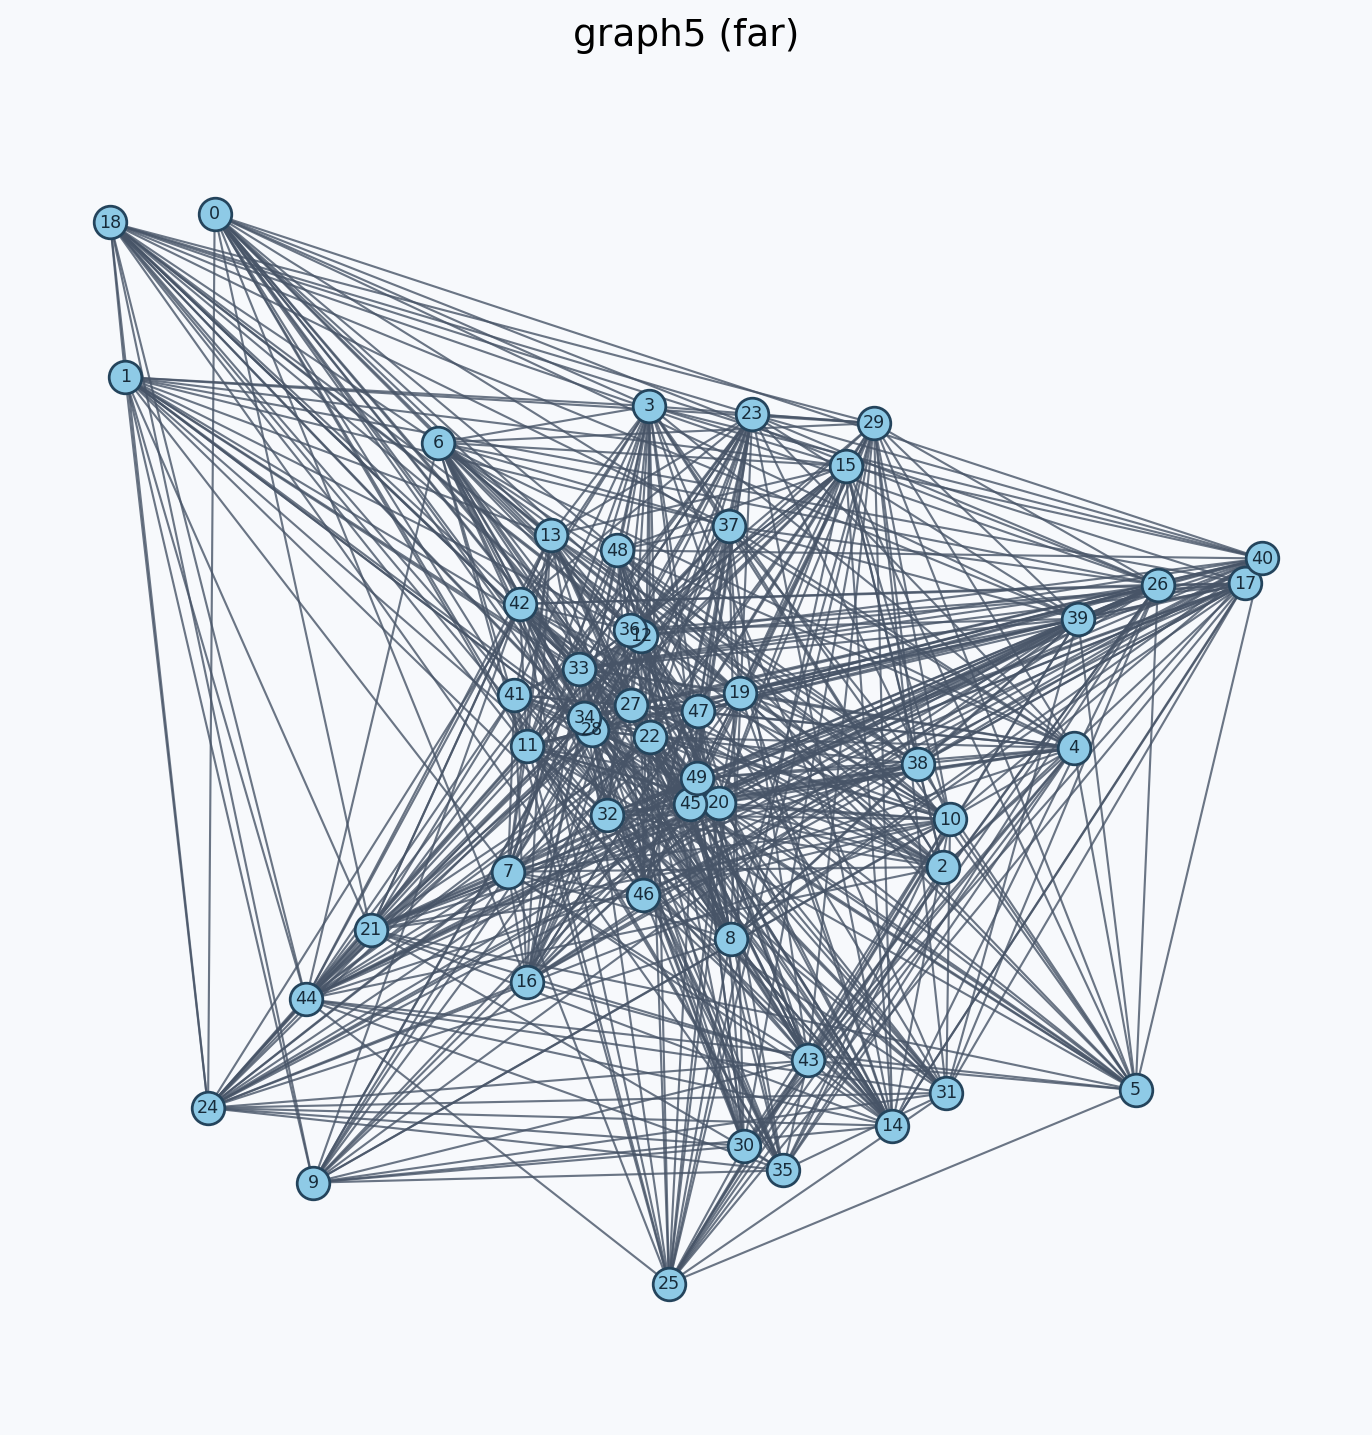

In [6]:
res1 = runGd(flags, mainPath, borderFlags=borderFlags, algoFlags=algoFlags)
print("stderr:", res1["stderr"])

png1 = runRender(mainPath, res1["jsonPath"])
display(Image(filename=str(png1)))

Вывод таблицы метрик:

In [8]:
setImageScore(res1, 1.0)

display(styleLogPairsTable(resultAsPairs(res1)))

поле,значение
volume,9282.772769
minVertexDist,1.078033
maxVertexDist,116.626052
avgVertexDist,39.861006
minEdgeVertexDist,0.004708
edgeCrossings,33394
minAngle,0.000218
maxAngle,3.140455
density,0.005386
imageScore,1.0


In [9]:
flags2 = [
    "--graph",
	"graph5",
	"--algo",
	"far",
    "--initial-placement",
    "random",
    "--space",
    "hyperbolic",
    "--dim",
    "2",
    "--projection",
    "poincare",
    "--2d",
    "--FS",
    "100, 100",
    "--dataset",
    "samples/dataset.json",
	"--output",
	"out/notebook/far/initTests/graph5Try2.json",
]

algoFlags2 = [
    "--C",
    "1.0",
    "--I",
    "100",
]

borderFlags2 = [
]

stderr: START
BorderPolicy default params, empty = defaults: FaR (--C --I), empty = defaults: 
saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/initTests/graph5Try2.png


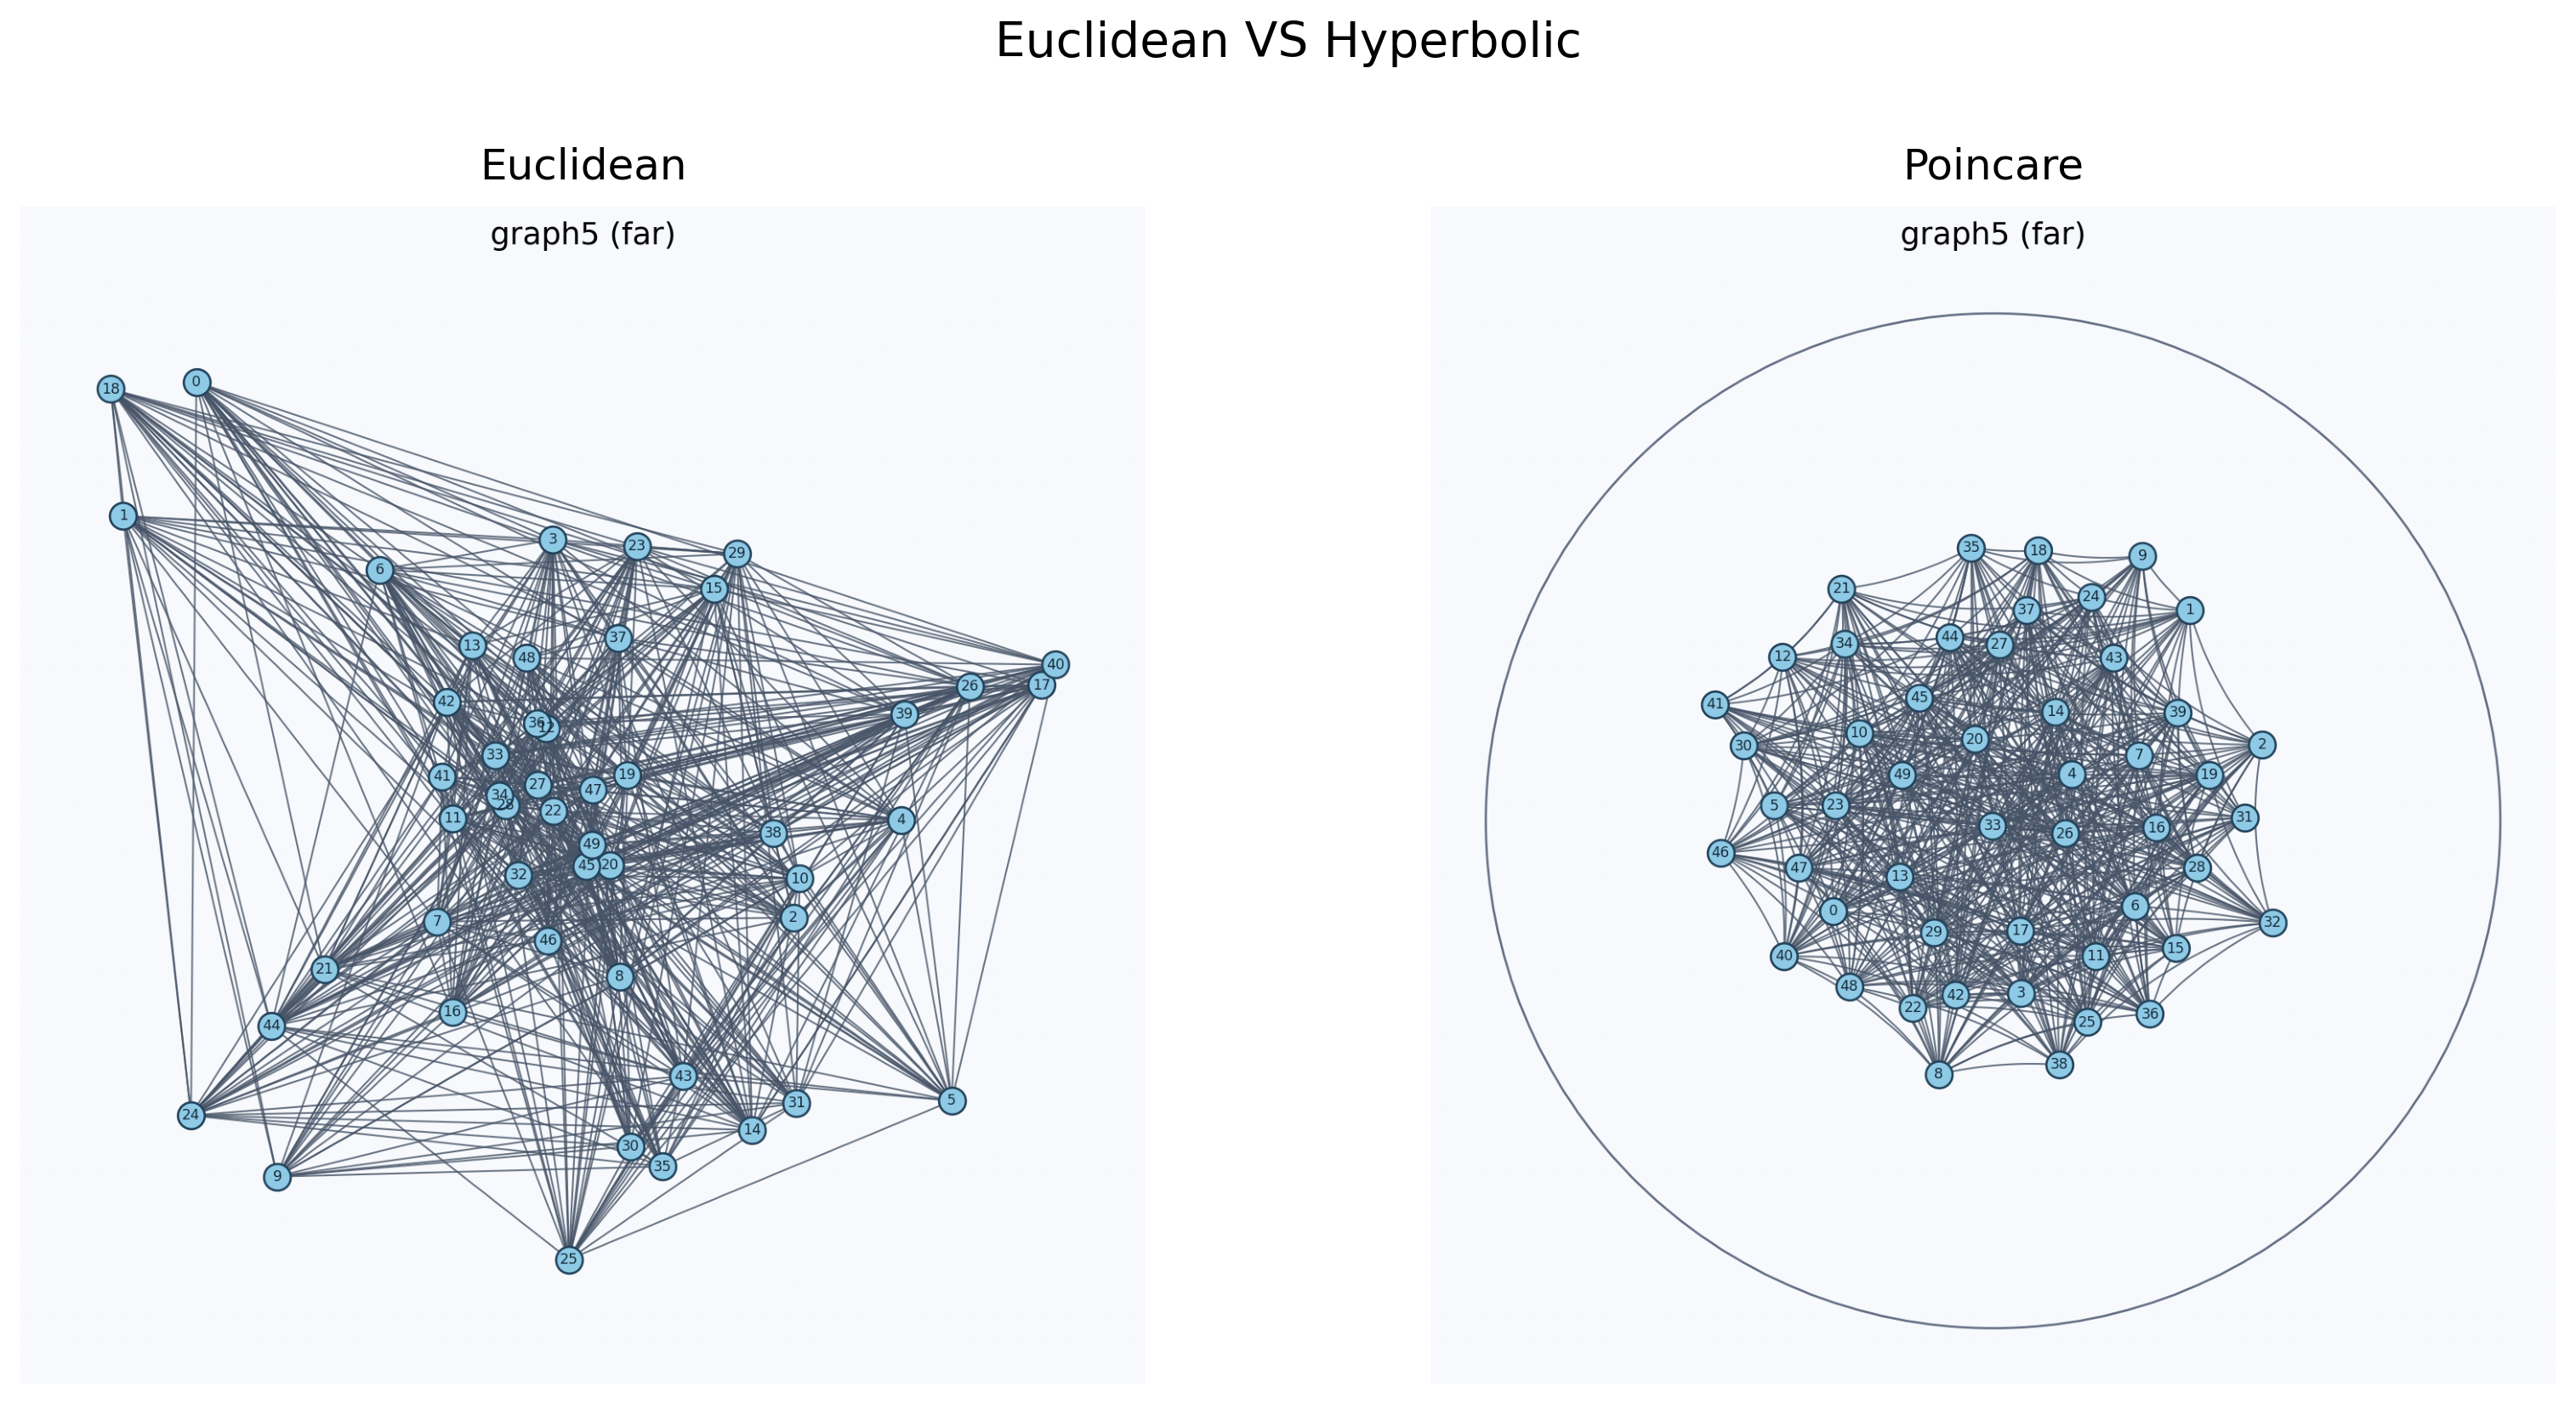

(<Figure size 1680x840 with 2 Axes>,
 array([<Axes: title={'center': 'Euclidean'}>,
        <Axes: title={'center': 'Poincare'}>], dtype=object))

In [10]:
res2 = runGd(flags2, mainPath, borderFlags=borderFlags2, algoFlags=algoFlags2)
print("stderr:", res2["stderr"])

png2 = runRender(mainPath, res2["jsonPath"])
# setImageScore(5.0)
displayTwo(
    png1,
    png2,
    title1="Euclidean",
    title2="Poincare",
    title="Euclidean VS Hyperbolic",
)

Вывод таблицы метрик:

поле,Euclidean,Poincare
volume,9282.772769,2850.919469
minVertexDist,1.078033,4.324829
maxVertexDist,116.626052,58.997695
avgVertexDist,39.861006,27.105522
minEdgeVertexDist,0.004708,0.002451
edgeCrossings,33394,33326
minAngle,0.000218,0.000278
maxAngle,3.140455,3.141366
density,0.005386,0.017538
imageScore,1.0,0


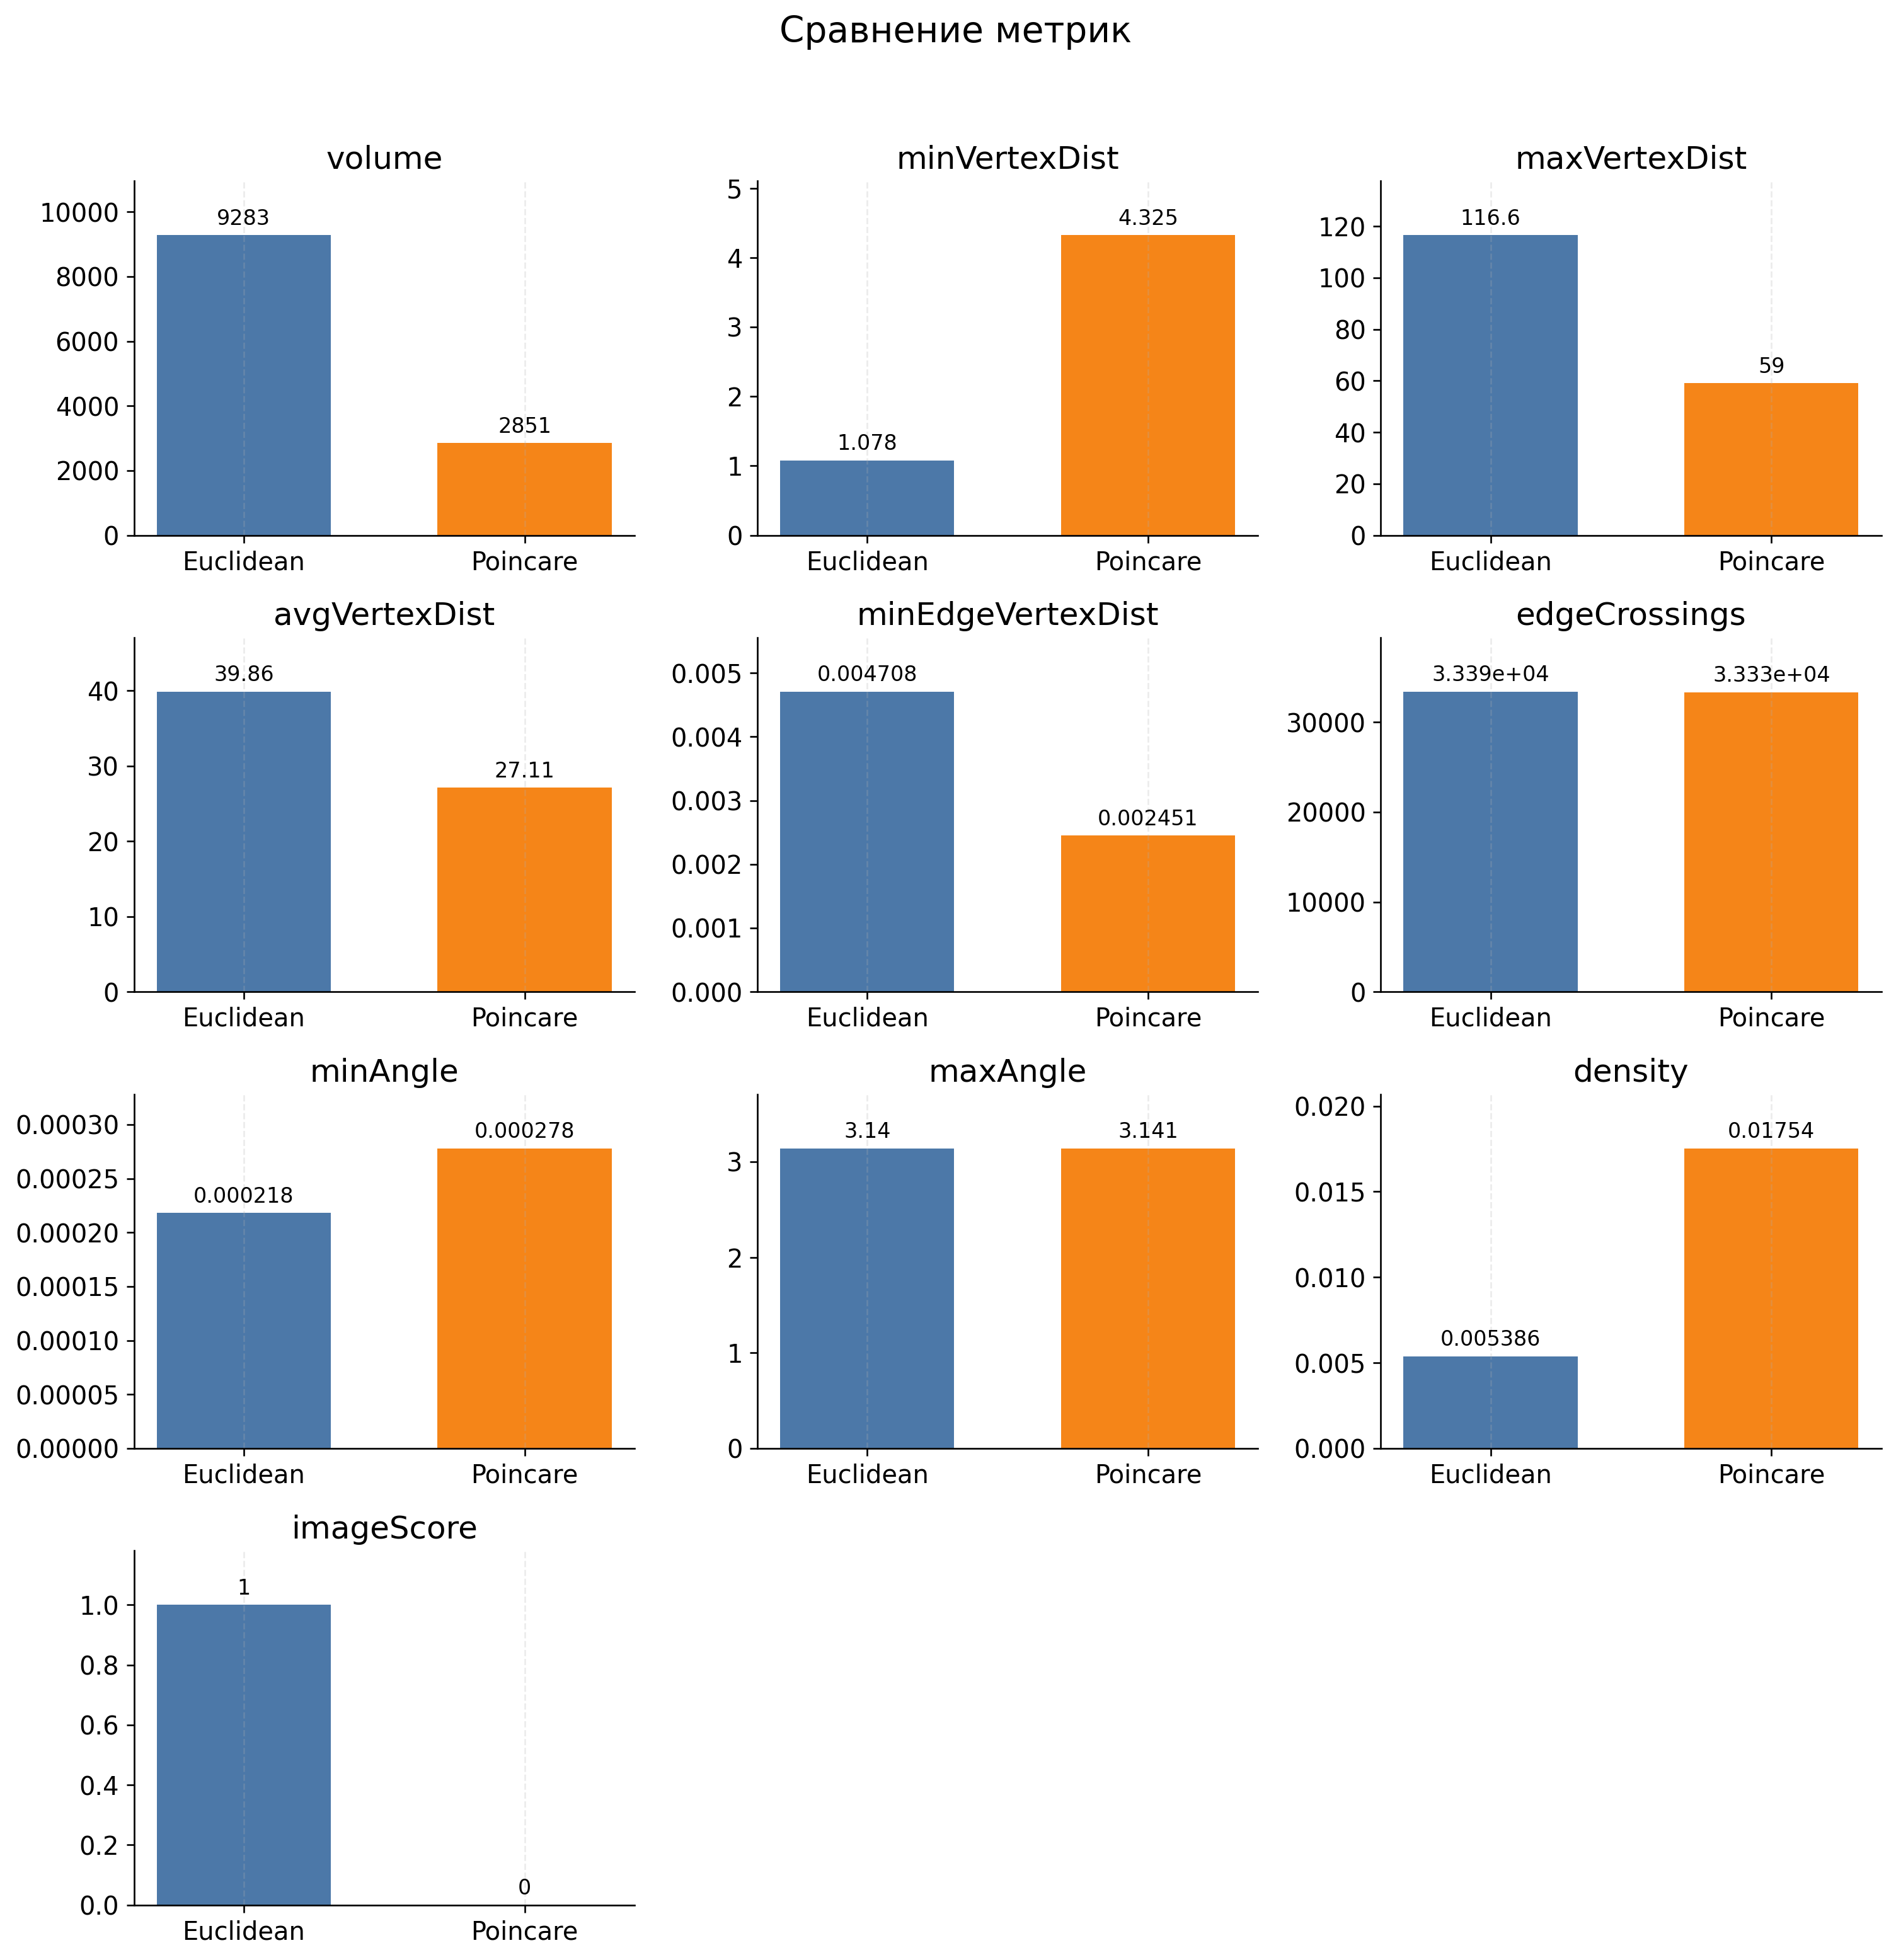

(<Figure size 1512x1584 with 12 Axes>,
 array([[<Axes: title={'center': 'volume'}>,
         <Axes: title={'center': 'minVertexDist'}>,
         <Axes: title={'center': 'maxVertexDist'}>],
        [<Axes: title={'center': 'avgVertexDist'}>,
         <Axes: title={'center': 'minEdgeVertexDist'}>,
         <Axes: title={'center': 'edgeCrossings'}>],
        [<Axes: title={'center': 'minAngle'}>,
         <Axes: title={'center': 'maxAngle'}>,
         <Axes: title={'center': 'density'}>],
        [<Axes: title={'center': 'imageScore'}>, <Axes: >, <Axes: >]],
       dtype=object))

In [11]:
table = compareResults(res1, res2, res1Label="Euclidean", res2Label="Poincare")
display(styleLogPairsTable(table))
plotMetricComparison(res1, res2, res1Label="Euclidean", res2Label="Poincare")

# Лучшие на n запусках

In [12]:
weights = {
	"volume": 1.0,
	"minVertexDist": 1.2,
	"maxVertexDist": 1.0,
	"avgVertexDist": 1.0,
	"edgeCrossings": 2.0,
	"minAngle": 2.0,
	"maxAngle": 1.0,
	"density": 1.2,
    "minEdgeVertexDist": 10.0,
	"imageScore": 0.0,
}

runCount = 100

def algoFlagsForRun1(iters):
	for _ in range(iters):
		yield algoFlags
		
def algoFlagsForRun2(iters):
	for _ in range(iters):
		yield algoFlags2
		
best1, scores1, allRuns1 = bestOfN(
	mainPath,
    flags,
	runCount,
	weights,
	algoFlags=algoFlags,
	algoFlagsForRun=algoFlagsForRun1,
)
best2, scores2, allRuns2 = bestOfN(
	mainPath,
    flags2,
	runCount,
	weights,
	algoFlags=algoFlags2,
	algoFlagsForRun=algoFlagsForRun2,
)


bestOfN graph5Try2: 100%|██████████| 100/100 [01:38<00:00,  1.02run/s]


In [13]:
png1 = runRender(mainPath, best1["jsonPath"])
png2 = runRender(mainPath, best2["jsonPath"])

saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/initTests/graph5Try1_batch_64.png
saved PNG to /Users/user/Code/Repos/GraphDrawing/out/notebook/far/initTests/graph5Try2_batch_29.png


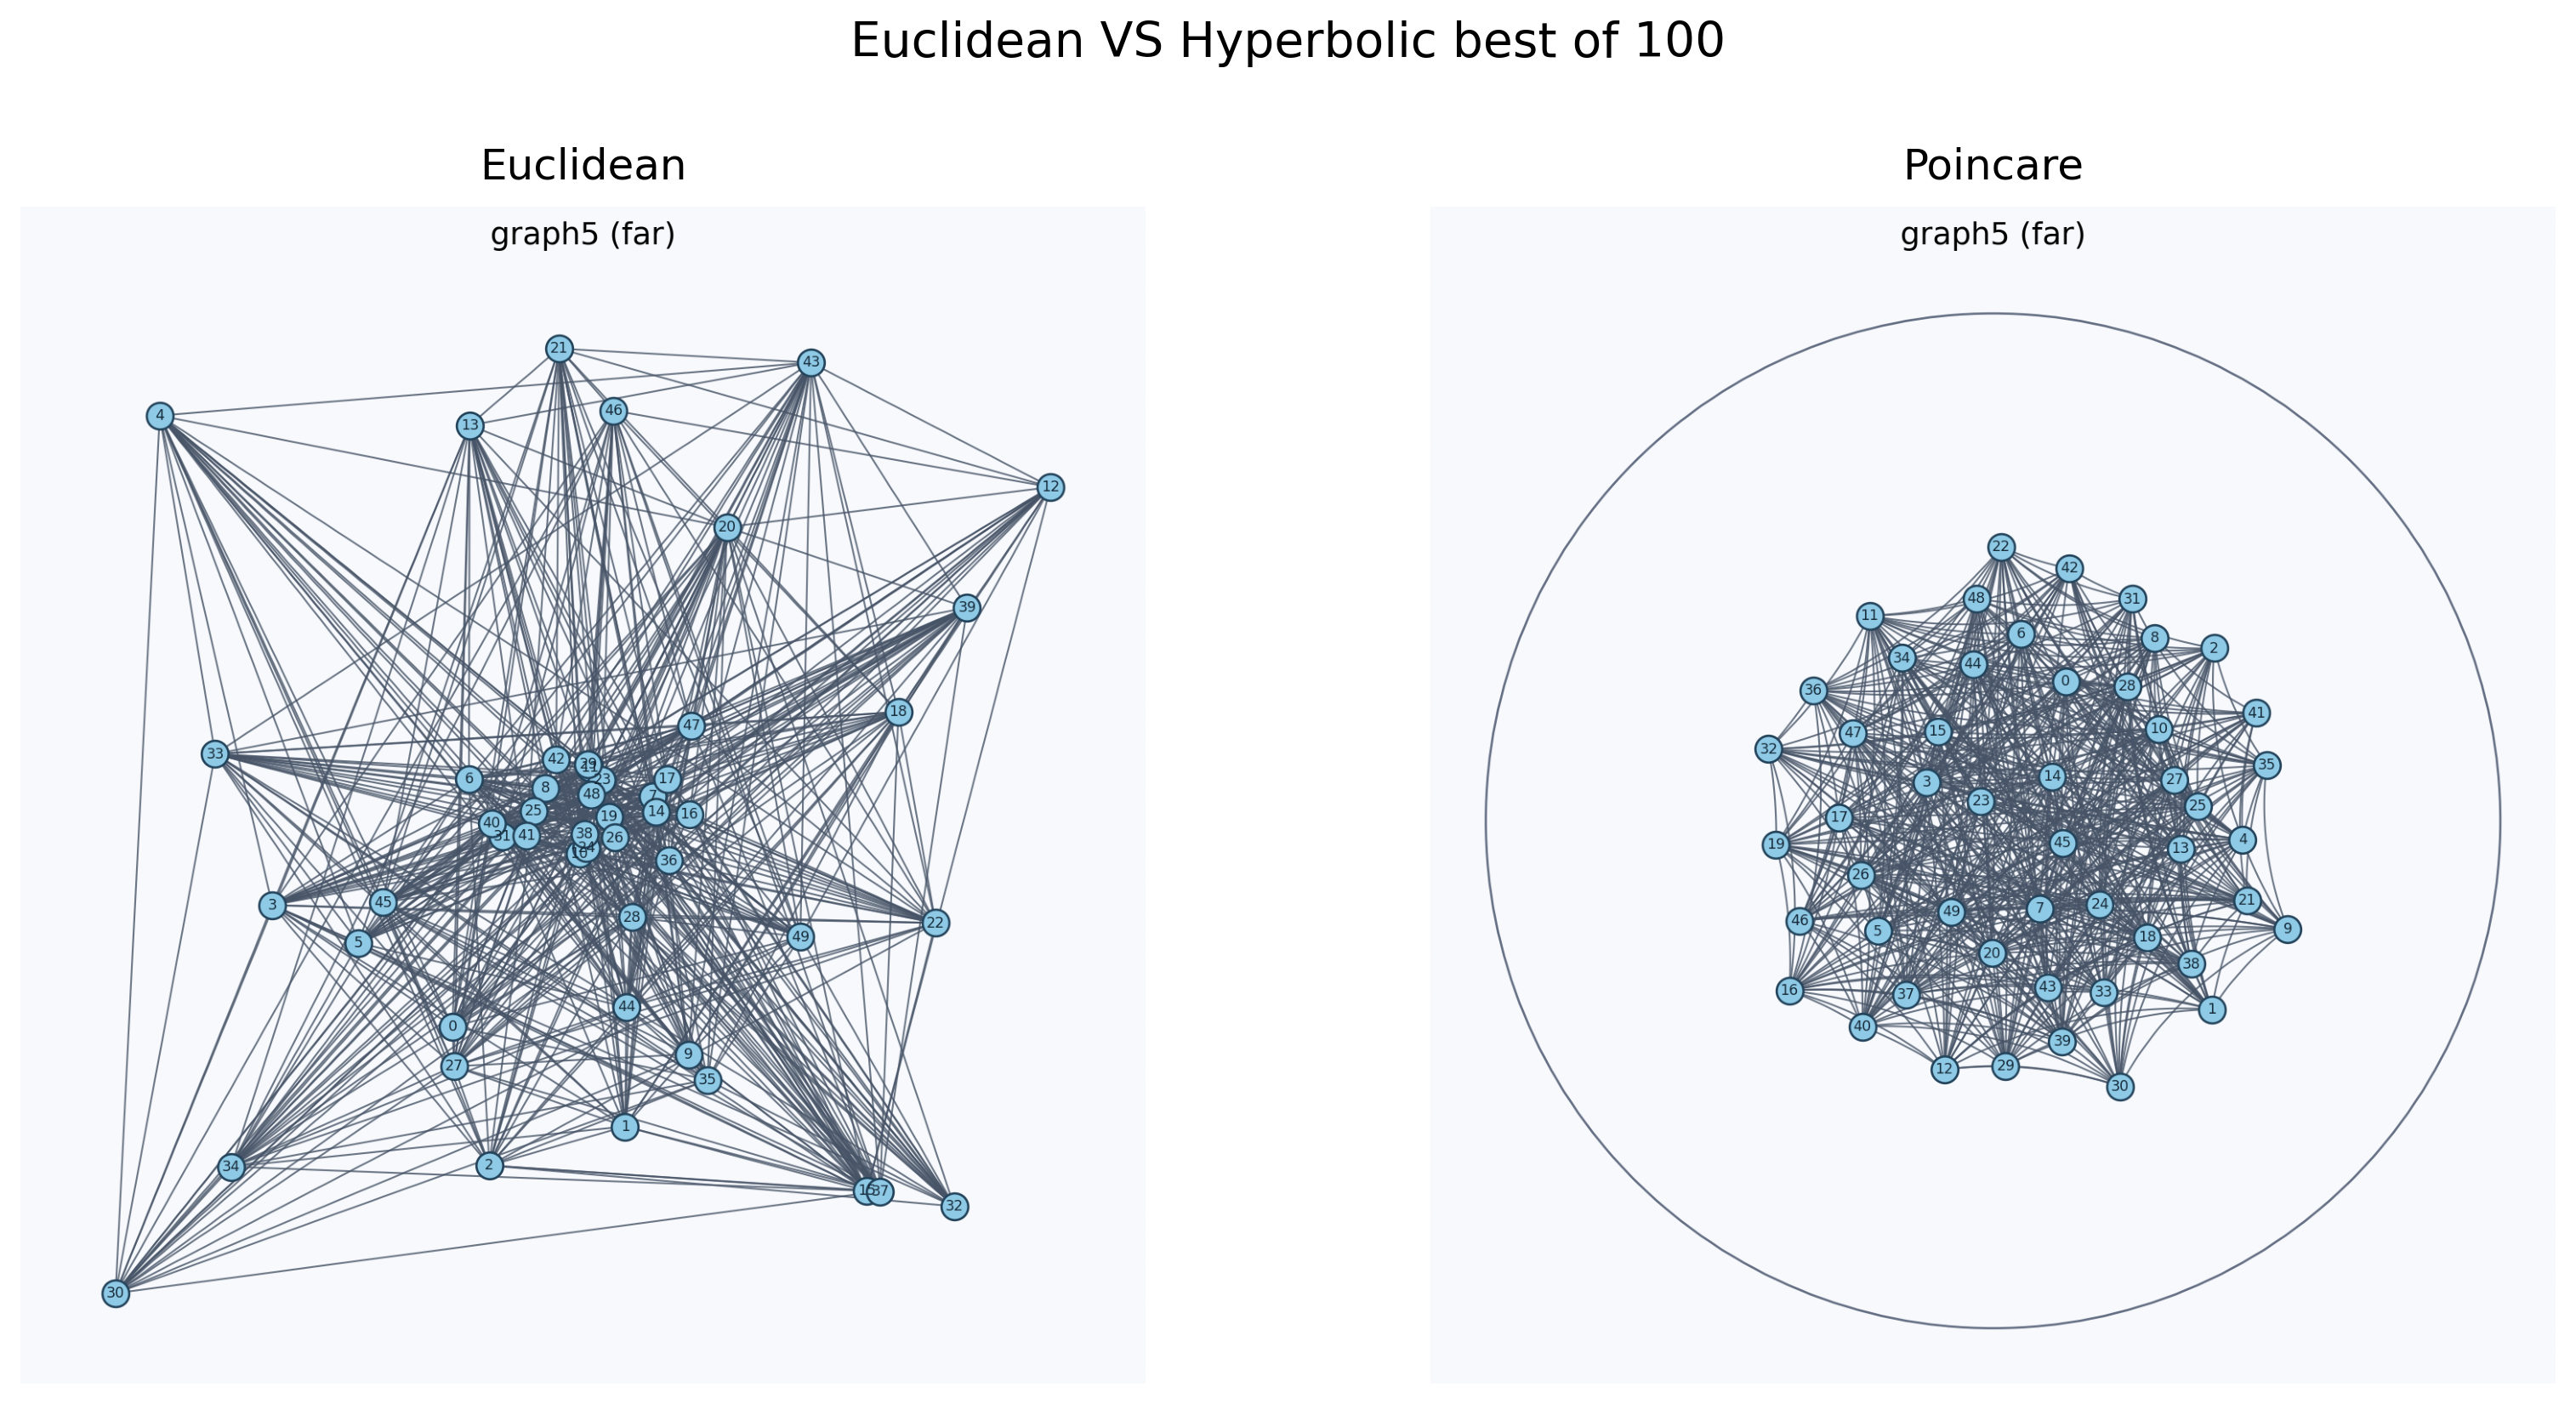

(<Figure size 1680x840 with 2 Axes>,
 array([<Axes: title={'center': 'Euclidean'}>,
        <Axes: title={'center': 'Poincare'}>], dtype=object))

In [14]:
displayTwo(
    png1,
    png2,
    title1="Euclidean",
    title2="Poincare",
    title="Euclidean VS Hyperbolic best of 100",
)

In [15]:
setImageScore(best1, 5.0)
setImageScore(best2, 4.0)

поле,Euclidean,Poincare
volume,9899.234878,2719.084154
minVertexDist,0.381127,3.482337
maxVertexDist,130.69516,54.401997
avgVertexDist,38.935789,26.664189
minEdgeVertexDist,0.010205,0.013694
edgeCrossings,29690,34421
minAngle,0.00027,0.00003
maxAngle,3.141431,3.140256
density,0.005051,0.018389
imageScore,5.0,4.0


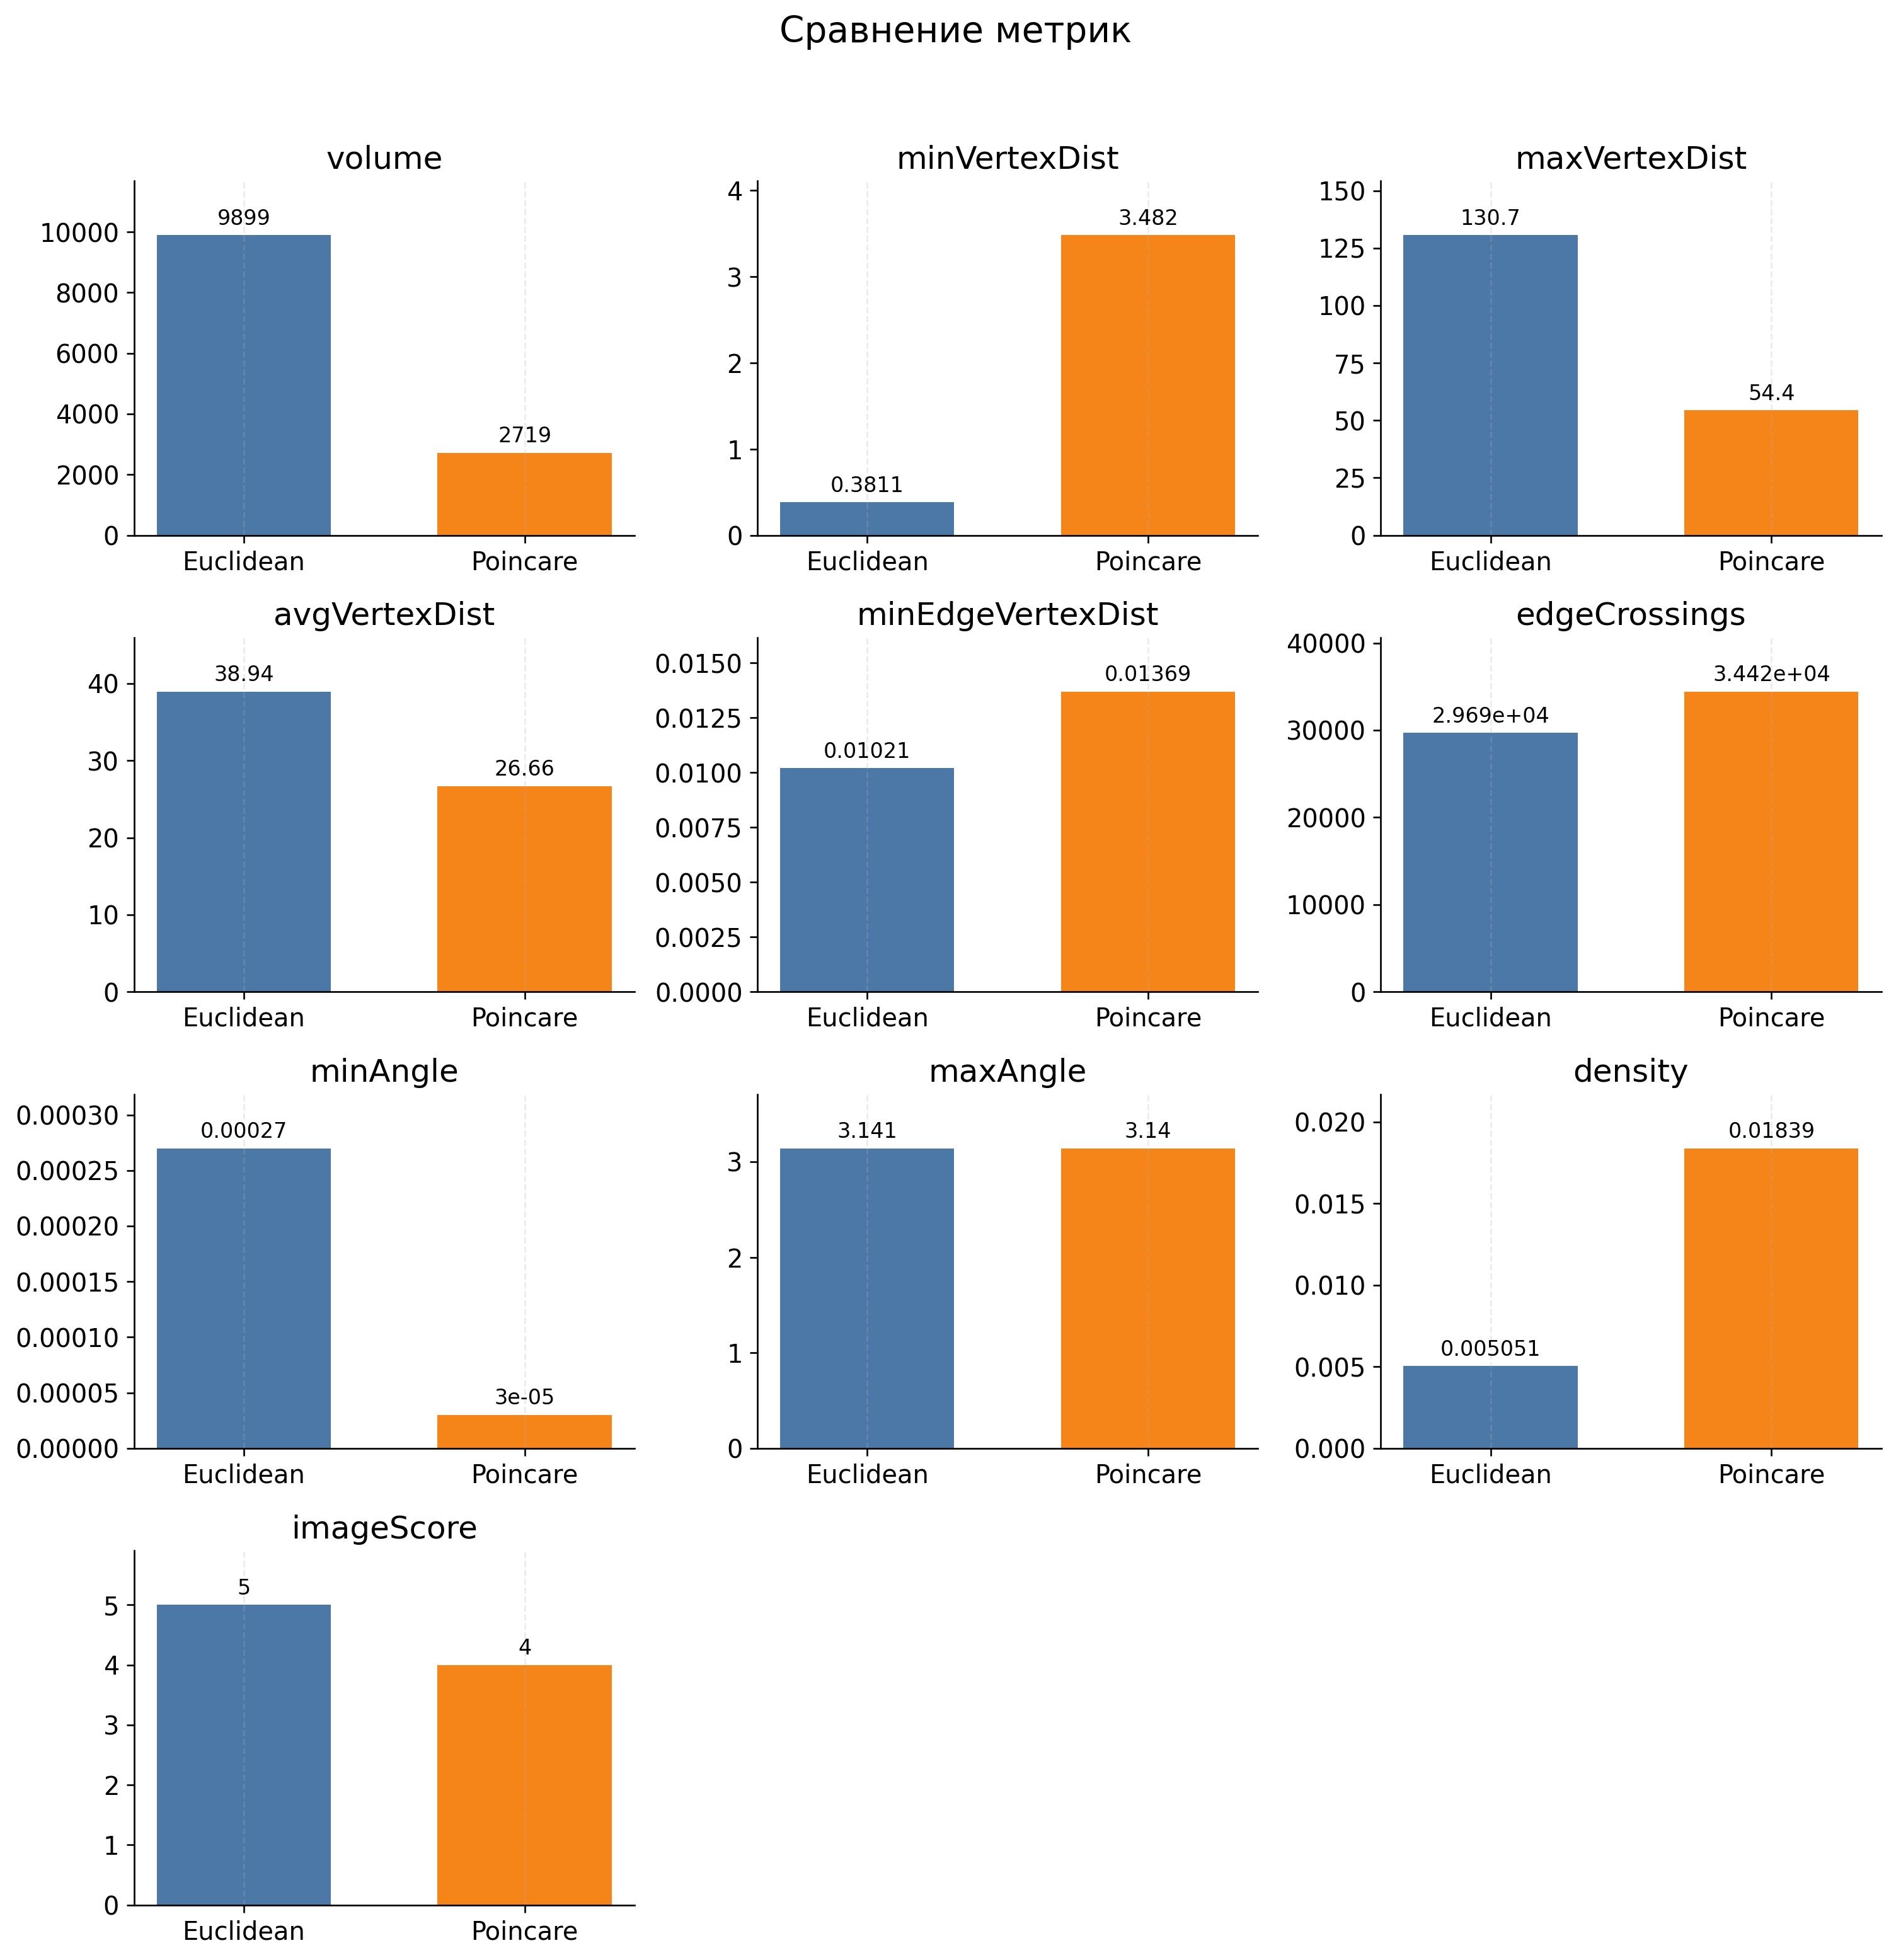

(<Figure size 1512x1584 with 12 Axes>,
 array([[<Axes: title={'center': 'volume'}>,
         <Axes: title={'center': 'minVertexDist'}>,
         <Axes: title={'center': 'maxVertexDist'}>],
        [<Axes: title={'center': 'avgVertexDist'}>,
         <Axes: title={'center': 'minEdgeVertexDist'}>,
         <Axes: title={'center': 'edgeCrossings'}>],
        [<Axes: title={'center': 'minAngle'}>,
         <Axes: title={'center': 'maxAngle'}>,
         <Axes: title={'center': 'density'}>],
        [<Axes: title={'center': 'imageScore'}>, <Axes: >, <Axes: >]],
       dtype=object))

In [16]:
table = compareResults(best1, best2, res1Label="Euclidean", res2Label="Poincare")
display(styleLogPairsTable(table))
plotMetricComparison(best1, best2, res1Label="Euclidean", res2Label="Poincare")